In [2]:
import torch
import matplotlib.pyplot as plt

# Classic model

In [3]:
output = torch.load('pretrained_model_and_stats/loss_stats.pth')

In [4]:
train_losses = output['train_losses']
val_losses = output['val_losses']
losses = output['all_losses']

/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/2040639613.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  best_idx = torch.argmin(torch.tensor(val_losses))


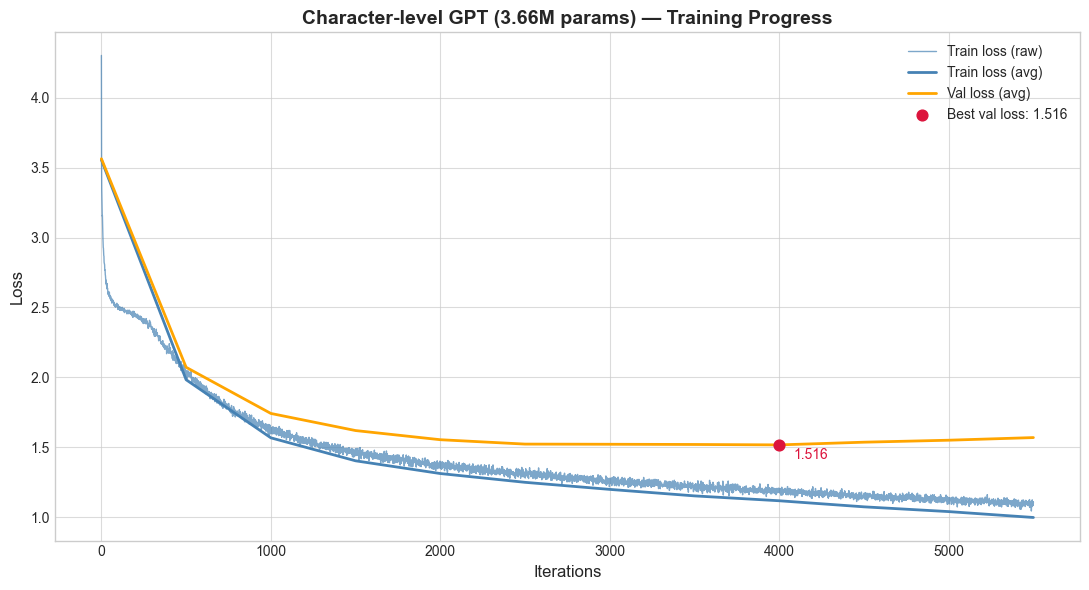

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlabel('Iterations', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Character-level GPT (3.66M params) — Training Progress', fontsize=14, fontweight='bold')
ax.plot(losses, label='Train loss (raw)', alpha=0.7, color='steelblue', linewidth=1)
iters_eval = torch.arange(len(train_losses)) * 500
ax.plot(iters_eval, train_losses, label='Train loss (avg)', linewidth=2, color='steelblue')
ax.plot(iters_eval, val_losses, label='Val loss (avg)', linewidth=2, color='orange')

best_idx = torch.argmin(torch.tensor(val_losses))
best_val = val_losses[best_idx]
best_iter = best_idx * 500
ax.scatter([best_iter], [best_val], color='crimson', zorder=5, s=60, label=f'Best val loss: {best_val:.3f}')
ax.annotate(f'{best_val:.3f}', (best_iter, best_val), textcoords="offset points", xytext=(10, -10), fontsize=10, color='crimson')

ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.7)

plt.tight_layout()
plt.savefig('pictures_and_graphs/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Fine-tuned Ceaser gpt

In [5]:
output_ceaser = torch.load('ceaser_gpt/loss_stats_ceaser.pth')

In [6]:
train_losses_ceaser = output_ceaser['train_losses']
val_losses_ceaser = output_ceaser['val_losses']
losses_ceaser = output_ceaser['all_losses']

/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/480153502.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  best_idx = torch.argmin(torch.tensor(val_losses_ceaser))


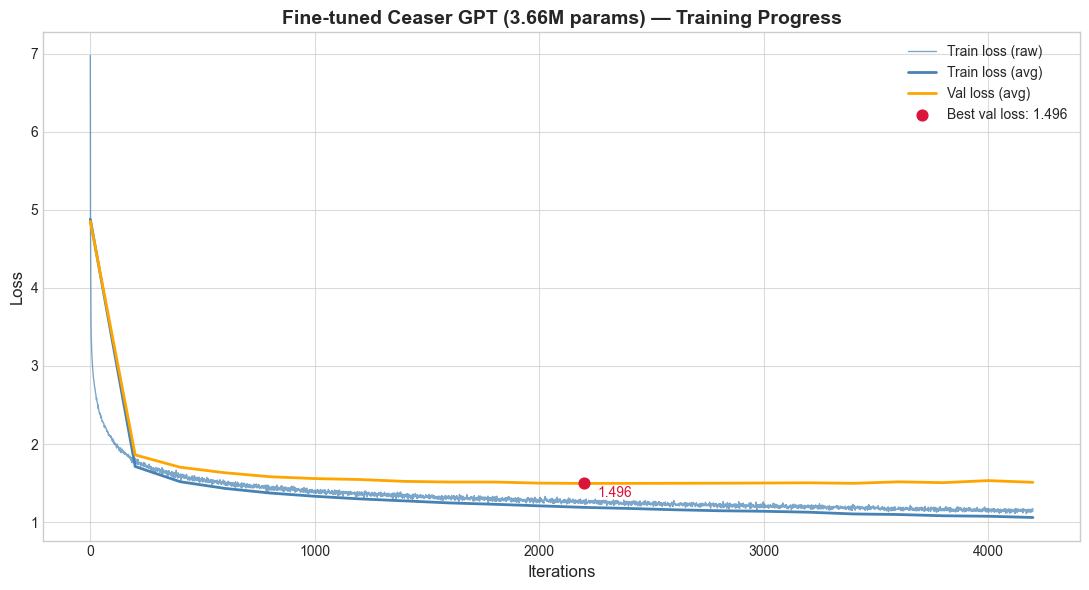

In [31]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlabel('Iterations', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Fine-tuned Ceaser GPT (3.66M params) — Training Progress', fontsize=14, fontweight='bold')
ax.plot(losses_ceaser, label='Train loss (raw)', alpha=0.7, color='steelblue', linewidth=1)
iters_eval = torch.arange(len(train_losses_ceaser)) * 200
ax.plot(iters_eval, train_losses_ceaser, label='Train loss (avg)', linewidth=2, color='steelblue')
ax.plot(iters_eval, val_losses_ceaser, label='Val loss (avg)', linewidth=2, color='orange')

best_idx = torch.argmin(torch.tensor(val_losses_ceaser))
best_val = val_losses_ceaser[best_idx]
best_iter = best_idx * 200
ax.scatter([best_iter], [best_val], color='crimson', zorder=5, s=60, label=f'Best val loss: {best_val:.3f}')
ax.annotate(f'{best_val:.3f}', (best_iter, best_val), textcoords="offset points", xytext=(10, -10), fontsize=10, color='crimson')

ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.7)

plt.tight_layout()
plt.savefig('pictures_and_graphs/ceaser_finetune_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Analysis

/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/3312109000.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  best_idx_scratch = torch.argmin(torch.tensor(val_losses))
/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/3312109000.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  best_idx_ft = torch.argmin(torch.tensor(val_losses_ceaser))


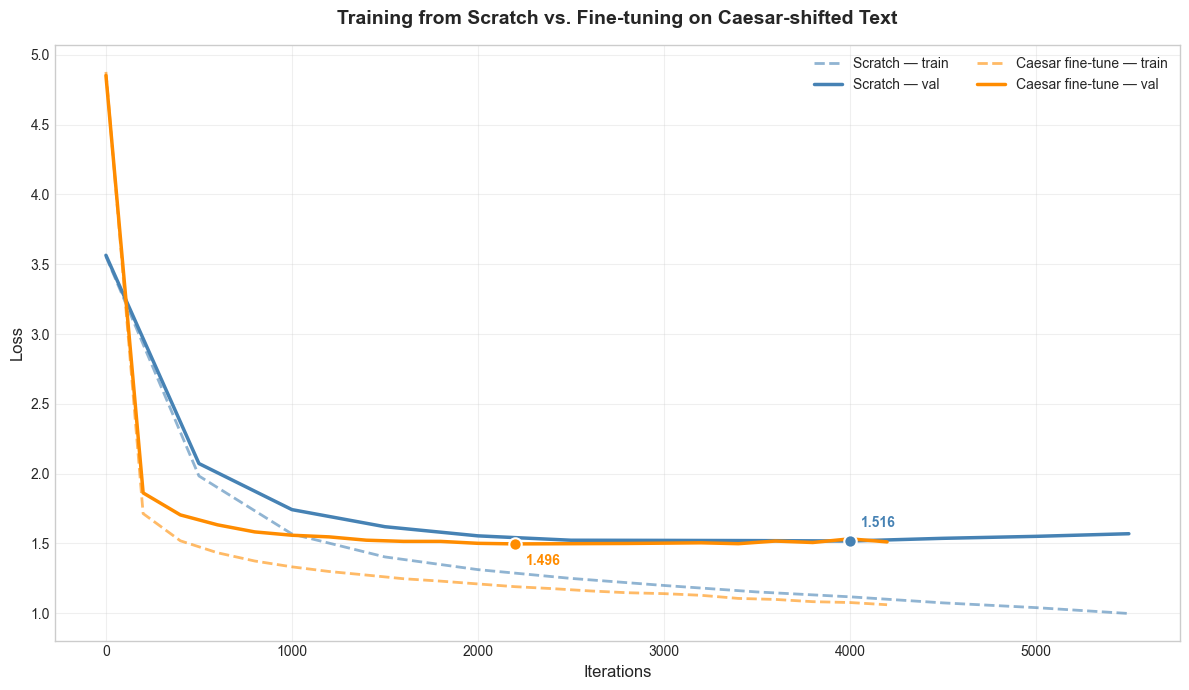

In [33]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# --- Classic GPT (обучение с нуля) — синяя пара ---
iters_scratch_train = torch.arange(len(train_losses)) * 500
iters_scratch_val = torch.arange(len(val_losses)) * 500

ax.plot(iters_scratch_train, train_losses, label='Scratch — train', 
        color='steelblue', linestyle='--', alpha=0.6, linewidth=2)
ax.plot(iters_scratch_val, val_losses, label='Scratch — val', 
        color='steelblue', linestyle='-', linewidth=2.5)

# --- Caesar fine-tuning — оранжевая пара ---
iters_ft_train = torch.arange(len(train_losses_ceaser)) * 200
iters_ft_val = torch.arange(len(val_losses_ceaser)) * 200

ax.plot(iters_ft_train, train_losses_ceaser, label='Caesar fine-tune — train', 
        color='darkorange', linestyle='--', alpha=0.6, linewidth=2)
ax.plot(iters_ft_val, val_losses_ceaser, label='Caesar fine-tune — val', 
        color='darkorange', linestyle='-', linewidth=2.5)

# --- Отметить лучший val loss для каждого эксперимента ---
best_idx_scratch = torch.argmin(torch.tensor(val_losses))
best_iter_scratch = iters_scratch_val[best_idx_scratch]
best_val_scratch = val_losses[best_idx_scratch]

best_idx_ft = torch.argmin(torch.tensor(val_losses_ceaser))
best_iter_ft = iters_ft_val[best_idx_ft]
best_val_ft = val_losses_ceaser[best_idx_ft]

ax.scatter([best_iter_scratch], [best_val_scratch], color='steelblue', 
           zorder=5, s=80, edgecolor='white', linewidth=1.5)
ax.annotate(f'{best_val_scratch:.3f}', (best_iter_scratch, best_val_scratch),
            textcoords="offset points", xytext=(8, 10), fontsize=10, color='steelblue', fontweight='bold')

ax.scatter([best_iter_ft], [best_val_ft], color='darkorange', 
           zorder=5, s=80, edgecolor='white', linewidth=1.5)
ax.annotate(f'{best_val_ft:.3f}', (best_iter_ft, best_val_ft),
            textcoords="offset points", xytext=(8, -15), fontsize=10, color='darkorange', fontweight='bold')

ax.set_xlabel('Iterations', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training from Scratch vs. Fine-tuning on Caesar-shifted Text', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pictures_and_graphs/classic_gpt_train_vs_finetune_ceaser_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

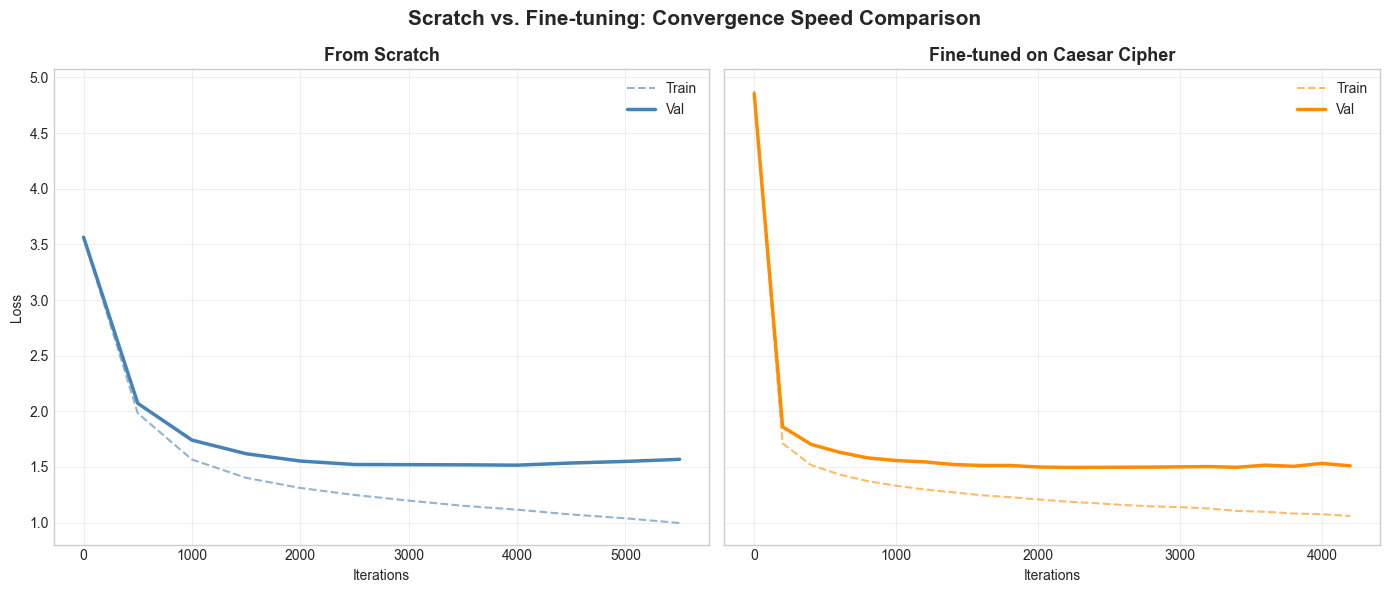

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].plot(iters_scratch_train, train_losses, '--', color='steelblue', alpha=0.6, label='Train')
axes[0].plot(iters_scratch_val, val_losses, '-', color='steelblue', linewidth=2.5, label='Val')
axes[0].set_title('From Scratch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters_ft_train, train_losses_ceaser, '--', color='darkorange', alpha=0.6, label='Train')
axes[1].plot(iters_ft_val, val_losses_ceaser, '-', color='darkorange', linewidth=2.5, label='Val')
axes[1].set_title('Fine-tuned on Caesar Cipher', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Scratch vs. Fine-tuning: Convergence Speed Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('pictures_and_graphs/train_finetune_speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/271271931.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  best_idx_scratch = torch.argmin(torch.tensor(val_losses))
/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/271271931.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  best_idx_ft = torch.argmin(torch.tensor(val_losses_ceaser))
/var/folders/sh/vd4xfx0s751452y9l4y5l2yc0000gn/T/ipykernel_6854/271271931.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_losses_ceaser_t = torch.tensor(val_losses

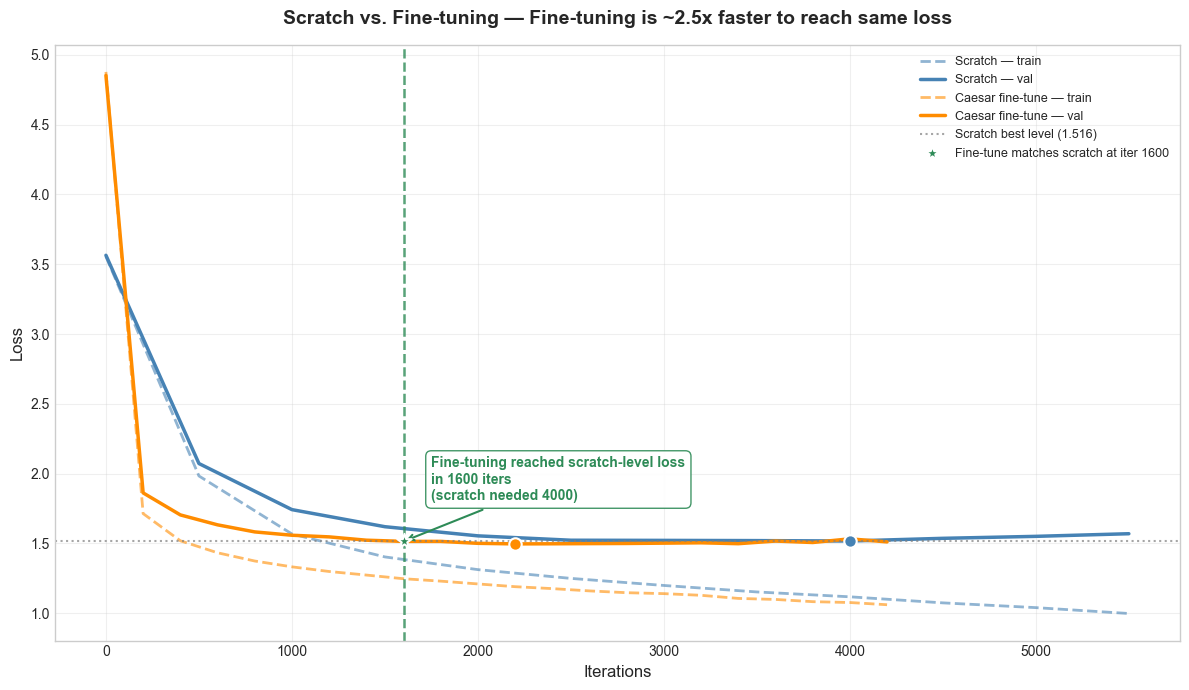

In [36]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# --- Classic GPT (обучение с нуля) — синяя пара ---
iters_scratch_train = torch.arange(len(train_losses)) * 500
iters_scratch_val = torch.arange(len(val_losses)) * 500

ax.plot(iters_scratch_train, train_losses, label='Scratch — train', 
        color='steelblue', linestyle='--', alpha=0.6, linewidth=2)
ax.plot(iters_scratch_val, val_losses, label='Scratch — val', 
        color='steelblue', linestyle='-', linewidth=2.5)

# --- Caesar fine-tuning — оранжевая пара ---
iters_ft_train = torch.arange(len(train_losses_ceaser)) * 200
iters_ft_val = torch.arange(len(val_losses_ceaser)) * 200

ax.plot(iters_ft_train, train_losses_ceaser, label='Caesar fine-tune — train', 
        color='darkorange', linestyle='--', alpha=0.6, linewidth=2)
ax.plot(iters_ft_val, val_losses_ceaser, label='Caesar fine-tune — val', 
        color='darkorange', linestyle='-', linewidth=2.5)

# --- Лучшие val loss точки для каждого эксперимента ---
best_idx_scratch = torch.argmin(torch.tensor(val_losses))
best_iter_scratch = iters_scratch_val[best_idx_scratch]
best_val_scratch = val_losses[best_idx_scratch]

best_idx_ft = torch.argmin(torch.tensor(val_losses_ceaser))
best_iter_ft = iters_ft_val[best_idx_ft]
best_val_ft = val_losses_ceaser[best_idx_ft]

ax.scatter([best_iter_scratch], [best_val_scratch], color='steelblue', 
           zorder=5, s=80, edgecolor='white', linewidth=1.5)
ax.scatter([best_iter_ft], [best_val_ft], color='darkorange', 
           zorder=5, s=80, edgecolor='white', linewidth=1.5)

# ---  Ключевая часть: момент, когда fine-tune достигает уровня scratch-модели ---
target_loss = best_val_scratch  # финальный (лучший) уровень scratch-модели

# горизонтальная линия-ориентир на уровне цели
ax.axhline(y=target_loss, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Scratch best level ({target_loss:.3f})')

# ищем первую итерацию, где val loss fine-tune модели <= target_loss
val_losses_ceaser_t = torch.tensor(val_losses_ceaser)
reached_mask = val_losses_ceaser_t <= target_loss

if reached_mask.any():
    reached_idx = torch.argmax(reached_mask.int())  # первый True
    reached_iter = iters_ft_val[reached_idx]
    reached_val = val_losses_ceaser[reached_idx]

    # вертикальная линия в этой точке
    ax.axvline(x=reached_iter, color='seagreen', linestyle='--', linewidth=1.8, alpha=0.8)
    ax.scatter([reached_iter], [reached_val], color='seagreen', zorder=6, s=120, 
               marker='*', edgecolor='white', linewidth=1.5,
               label=f'Fine-tune matches scratch at iter {int(reached_iter)}')

    # текстовая аннотация со сравнением скорости
    speedup_text = f'Fine-tuning reached scratch-level loss\nin {int(reached_iter)} iters\n(scratch needed {int(best_iter_scratch)})'
    ax.annotate(speedup_text, (reached_iter, reached_val),
                textcoords="offset points", xytext=(20, 30), fontsize=10,
                color='seagreen', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='seagreen', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.5))
else:
    print(f'Fine-tuning модель ещё не достигла уровня {target_loss:.3f} за {epochs} эпох')

ax.set_xlabel('Iterations', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training from Scratch vs. Fine-tuning on Caesar-shifted Text', 
             fontsize=14, fontweight='bold', pad=15)
if reached_mask.any():
    speedup = best_iter_scratch / reached_iter if reached_iter > 0 else float('inf')
    ax.set_title(f'Scratch vs. Fine-tuning — Fine-tuning is ~{speedup:.1f}x faster to reach same loss', 
                 fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9, ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pictures_and_graphs/finetune_reach_same_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Embedding comparison

In [7]:
model_scratch = torch.load('pretrained_model_and_stats/best_gpt_classic.pth', map_location='cpu')

In [8]:
model_scratch_weights = model_scratch['model_state_dict']

In [9]:
scratch_embeddings = model_scratch_weights['embedding.weight']

In [10]:
model_finetune = torch.load('ceaser_gpt/best_gpt_ceaser.pth', map_location='cpu')
model_finetune_weights = model_finetune['model_state_dict']
finetune_embeddings = model_finetune_weights['embedding.weight']

In [11]:
scratch_embeddings

tensor([[-0.7801,  1.0781, -2.0589,  ...,  0.5776, -1.4152,  0.5631],
        [-0.9915,  0.1729,  1.5627,  ...,  0.7118,  1.2607,  1.5470],
        [ 0.9225,  1.5084, -1.0428,  ...,  0.1736,  0.9791,  2.0637],
        ...,
        [ 1.6256,  1.8070, -1.6824,  ...,  0.9417,  0.7917, -0.4708],
        [-0.9563,  0.6153, -0.1048,  ...,  0.7199,  0.3331, -0.7583],
        [ 1.0780, -0.3487, -2.0927,  ..., -0.6883,  0.0487,  1.5273]])

In [12]:
finetune_embeddings

tensor([[-0.7903,  1.0540, -2.0519,  ...,  0.5611, -1.4212,  0.5592],
        [-0.9947,  0.1780,  1.5555,  ...,  0.7069,  1.2620,  1.5383],
        [ 0.9371,  1.4913, -1.0836,  ...,  0.1646,  0.9832,  2.0458],
        ...,
        [ 1.6251,  1.8074, -1.6708,  ...,  0.9330,  0.8100, -0.4780],
        [-0.9080,  0.6237, -0.0931,  ...,  0.7641,  0.3236, -0.8624],
        [ 1.0407, -0.3352, -2.1052,  ..., -0.6851,  0.0096,  1.5135]])

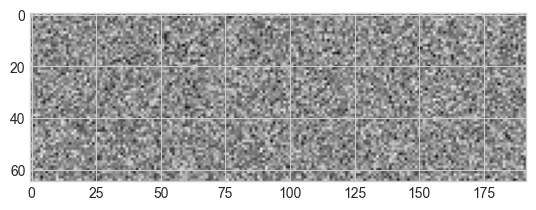

In [55]:
plt.imshow(scratch_embeddings);

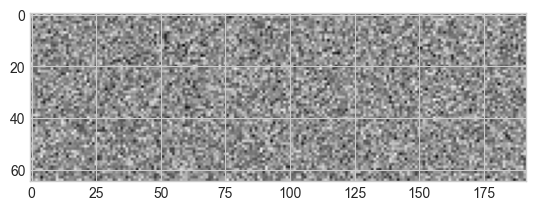

In [56]:
plt.imshow(finetune_embeddings);

In [13]:
alph = f"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
stoi = {c:i for i, c in enumerate(alph)}
itos = {v:k for k,v in stoi.items()}

In [14]:
len(alph)

65

In [15]:
def encode_ceaser(text, shift=1):
    result = []
    for c in text:
        if 'a' <= c <= 'z':
            result.append(chr((ord(c) - ord('a') + shift) % 26 + ord('a')))
        elif 'A' <= c <= 'Z':
            result.append(chr((ord(c) - ord('A') + shift) % 26 + ord('A')))
        else:
            result.append(c)
    return ''.join(result)

def decode_ceaser(text, shift=1):
    return encode_ceaser(text, shift=-shift)

In [16]:
import torch.nn.functional as F

# сравниваем эмбеддинг буквы X в fine-tuned модели с:
# (а) эмбеддингом той же буквы X в scratch модели
# (б) эмбеддингом сдвинутой буквы (X-1) в scratch модели — гипотеза сдвига

results = []
for ch in alph:
    if ch.isalpha():
        idx = stoi[ch]
        # какая буква была ДО шифрования (сдвиг -1)
        original_ch = decode_ceaser(ch, shift=1)  # или decode, если так называется ваша функция шифра
        if original_ch in stoi:
            orig_idx = stoi[original_ch]

            emb_ft = finetune_embeddings[idx]         # эмбеддинг буквы ch в fine-tuned модели
            emb_same_scratch = scratch_embeddings[idx]  # эмбеддинг той же буквы ch в scratch
            emb_shifted_scratch = scratch_embeddings[orig_idx]  # эмбеддинг ИСХОДНОЙ буквы в scratch

            sim_same = F.cosine_similarity(emb_ft.unsqueeze(0), emb_same_scratch.unsqueeze(0)).item()
            sim_shifted = F.cosine_similarity(emb_ft.unsqueeze(0), emb_shifted_scratch.unsqueeze(0)).item()

            results.append({
                'letter': ch,
                'original_letter': original_ch,
                'sim_to_same_letter': sim_same,
                'sim_to_shifted_letter': sim_shifted,
            })

import pandas as pd
df = pd.DataFrame(results)
print(df)
print(f"\nСреднее сходство с той же буквой: {df['sim_to_same_letter'].mean():.4f}")
print(f"Среднее сходство со сдвинутой буквой: {df['sim_to_shifted_letter'].mean():.4f}")

   letter original_letter  sim_to_same_letter  sim_to_shifted_letter
0       A               Z            0.998781               0.132631
1       B               A            0.999837               0.100593
2       C               B            0.999741               0.027479
3       D               C            0.999691               0.039048
4       E               D            0.999166              -0.093460
5       F               E            0.999839               0.020199
6       G               F            0.999656               0.070023
7       H               G            0.999701              -0.034930
8       I               H            0.999733               0.161028
9       J               I            0.999884              -0.031439
10      K               J            0.999570              -0.127768
11      L               K            0.999179               0.054537
12      M               L            0.999740               0.037405
13      N               M         

In [19]:
df.head(20)

,letter,original_letter,sim_to_same_letter,sim_to_shifted_letter
0,A,Z,0.998781,0.132631
1,B,A,0.999837,0.100593
2,C,B,0.999741,0.027479
3,D,C,0.999691,0.039048
4,E,D,0.999166,-0.093460
5,F,E,0.999839,0.020199
6,G,F,0.999656,0.070023
7,H,G,0.999701,-0.034930
8,I,H,0.999733,0.161028
9,J,I,0.999884,-0.031439


In [93]:
diff_norms = torch.norm(finetune_embeddings - scratch_embeddings, dim=1)
print(diff_norms.describe() if hasattr(diff_norms, 'describe') else diff_norms.mean(), diff_norms.std())

tensor(0.3736) tensor(0.1903)


In [94]:
for i in range(8):
    ff_diff = torch.norm(model_finetune_weights[f'blocks.{i}.ff.lin1.weight'] - model_scratch_weights[f'blocks.{i}.ff.lin1.weight'])
    print(f'Block {i} FF lin1 weight diff (Frobenius norm): {ff_diff.item():.4f}')

Block 0 FF lin1 weight diff (Frobenius norm): 4.6256
Block 1 FF lin1 weight diff (Frobenius norm): 3.6017
Block 2 FF lin1 weight diff (Frobenius norm): 3.1746
Block 3 FF lin1 weight diff (Frobenius norm): 3.3936
Block 4 FF lin1 weight diff (Frobenius norm): 5.6874
Block 5 FF lin1 weight diff (Frobenius norm): 7.9370
Block 6 FF lin1 weight diff (Frobenius norm): 9.2149
Block 7 FF lin1 weight diff (Frobenius norm): 9.5449


In [95]:
for i in range(8):
    ff_diff = torch.norm(model_finetune_weights[f'blocks.{i}.ff.lin2.weight'] - model_scratch_weights[f'blocks.{i}.ff.lin2.weight'])
    print(f'Block {i} FF lin1 weight diff (Frobenius norm): {ff_diff.item():.4f}')

Block 0 FF lin1 weight diff (Frobenius norm): 4.2761
Block 1 FF lin1 weight diff (Frobenius norm): 3.6309
Block 2 FF lin1 weight diff (Frobenius norm): 3.1450
Block 3 FF lin1 weight diff (Frobenius norm): 2.4356
Block 4 FF lin1 weight diff (Frobenius norm): 4.7139
Block 5 FF lin1 weight diff (Frobenius norm): 7.1512
Block 6 FF lin1 weight diff (Frobenius norm): 8.2097
Block 7 FF lin1 weight diff (Frobenius norm): 6.7419


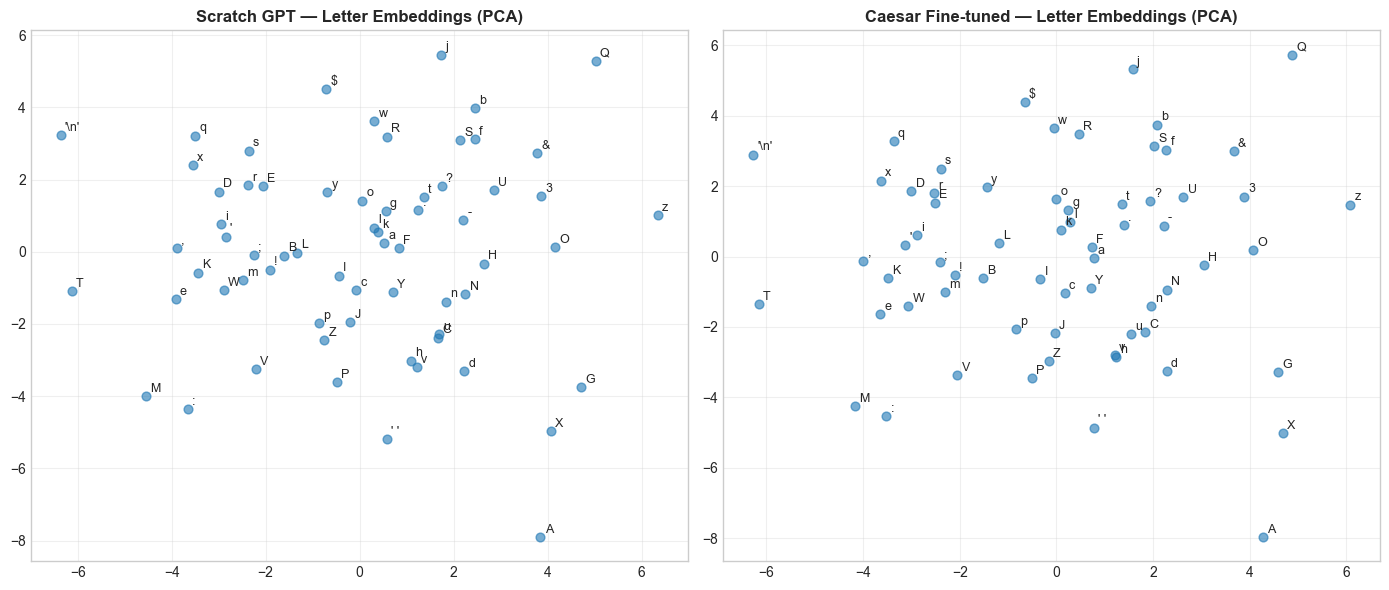

In [97]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_embeddings_pca(emb, itos, title, ax):
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb.numpy())
    
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.6, s=40)
    for i, (x, y) in enumerate(emb_2d):
        ch = itos[i]
        ax.annotate(repr(ch) if ch in ('\n', ' ') else ch, (x, y), 
                    fontsize=9, xytext=(3, 3), textcoords='offset points')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_embeddings_pca(scratch_embeddings, itos, 'Scratch GPT — Letter Embeddings (PCA)', axes[0])
plot_embeddings_pca(finetune_embeddings, itos, 'Caesar Fine-tuned — Letter Embeddings (PCA)', axes[1])
plt.tight_layout()
plt.savefig('pictures_and_graphs/embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

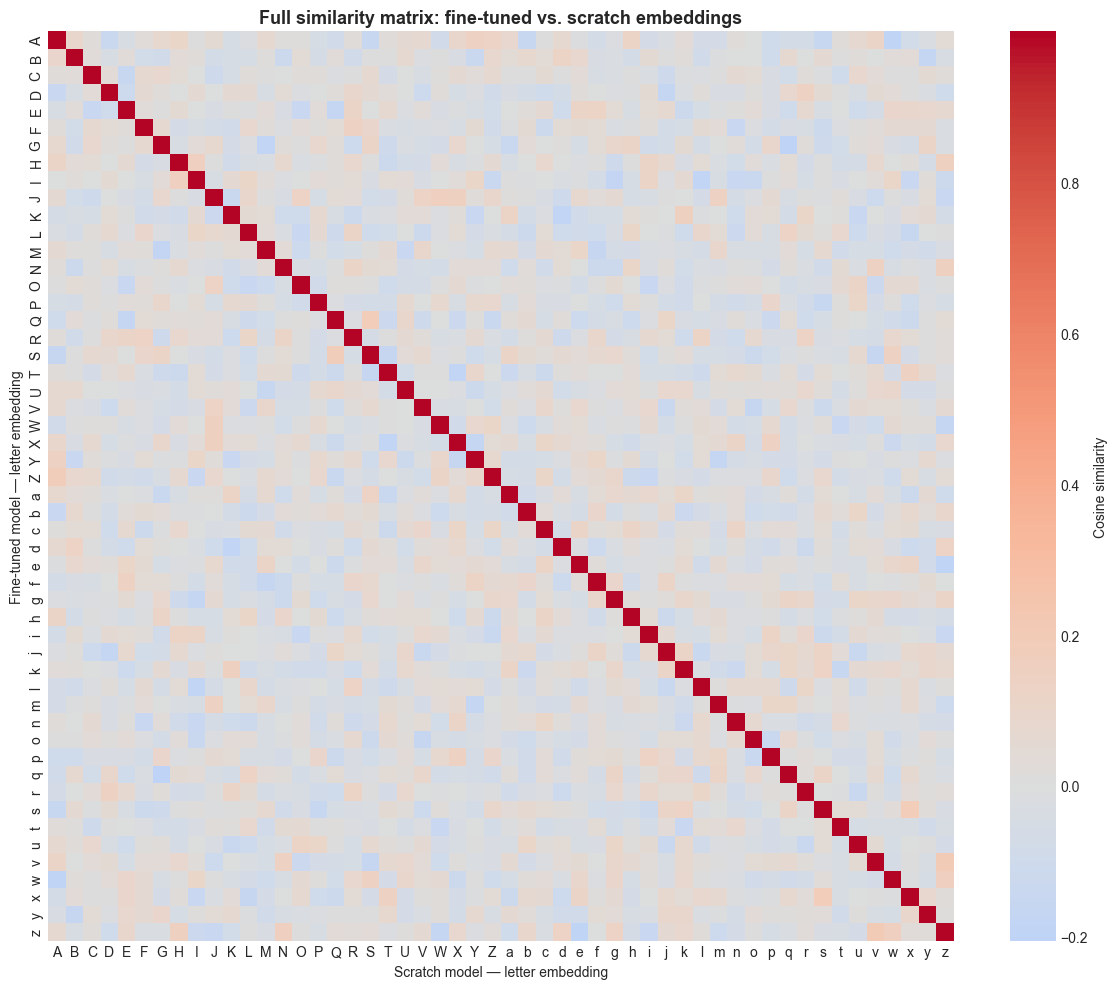

In [100]:
import seaborn as sns

letters = [c for c in alph if c.isalpha()]
letter_idxs = [stoi[c] for c in letters]

emb_ft_letters = finetune_embeddings[letter_idxs]
emb_scratch_letters = scratch_embeddings[letter_idxs]

sim_matrix = F.cosine_similarity(
    emb_ft_letters.unsqueeze(1), emb_scratch_letters.unsqueeze(0), dim=-1
).numpy()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=letters, yticklabels=letters, 
            cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Cosine similarity'})
ax.set_xlabel('Scratch model — letter embedding')
ax.set_ylabel('Fine-tuned model — letter embedding')
ax.set_title('Full similarity matrix: fine-tuned vs. scratch embeddings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pictures_and_graphs/embedding_cosine_similarity_map.png', dpi=150, bbox_inches='tight')
plt.show()

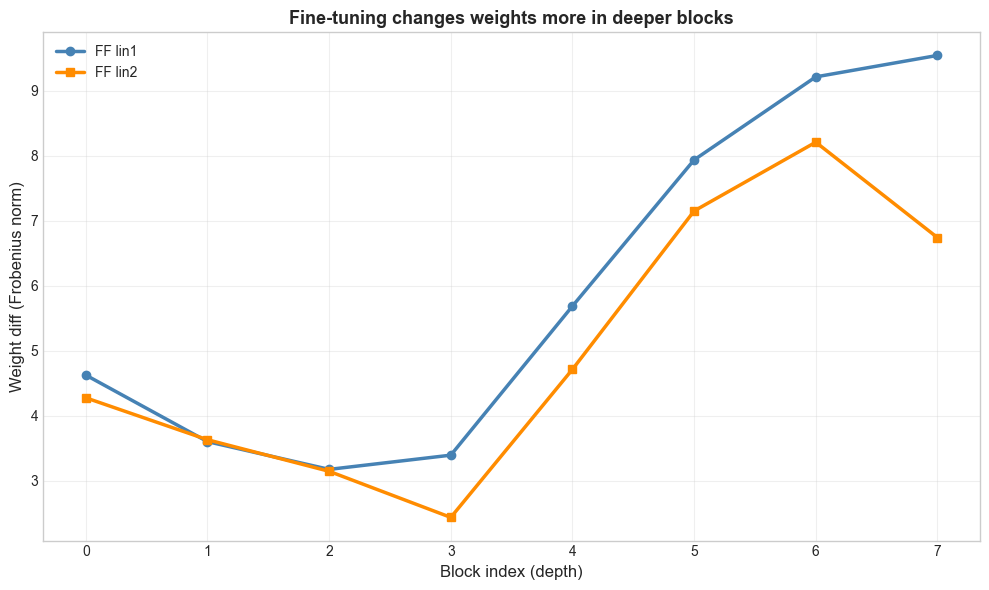

In [103]:
import matplotlib.pyplot as plt

blocks = list(range(8))
lin1_diffs = [4.6256, 3.6017, 3.1746, 3.3936, 5.6874, 7.9370, 9.2149, 9.5449]
lin2_diffs = [4.2761, 3.6309, 3.1450, 2.4356, 4.7139, 7.1512, 8.2097, 6.7419]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(blocks, lin1_diffs, marker='o', label='FF lin1', linewidth=2.5, color='steelblue')
ax.plot(blocks, lin2_diffs, marker='s', label='FF lin2', linewidth=2.5, color='darkorange')
ax.set_xlabel('Block index (depth)', fontsize=12)
ax.set_ylabel('Weight diff (Frobenius norm)', fontsize=12)
ax.set_title('Fine-tuning changes weights more in deeper blocks', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pictures_and_graphs/FF_layer_change.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
for i in range(8):
    attn_diff = torch.norm(model_finetune_weights[f'blocks.{i}.attn.in_proj_weight'] - model_scratch_weights[f'blocks.{i}.attn.in_proj_weight'])
    print(f'Block {i} Attention in_proj weight diff: {attn_diff.item():.4f}')

Block 0 Attention in_proj weight diff: 3.0938
Block 1 Attention in_proj weight diff: 2.2677
Block 2 Attention in_proj weight diff: 2.5598
Block 3 Attention in_proj weight diff: 2.4429
Block 4 Attention in_proj weight diff: 3.8271
Block 5 Attention in_proj weight diff: 6.2038
Block 6 Attention in_proj weight diff: 7.6373
Block 7 Attention in_proj weight diff: 7.5462


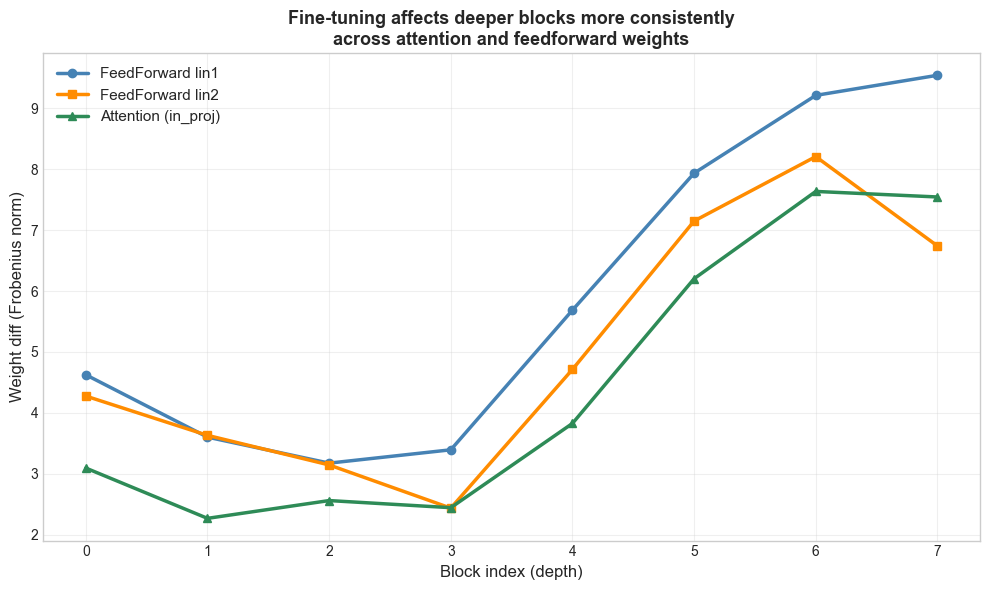

In [107]:
import matplotlib.pyplot as plt

blocks = list(range(8))
lin1_diffs = [4.6256, 3.6017, 3.1746, 3.3936, 5.6874, 7.9370, 9.2149, 9.5449]
lin2_diffs = [4.2761, 3.6309, 3.1450, 2.4356, 4.7139, 7.1512, 8.2097, 6.7419]
attn_diffs = [3.0938, 2.2677, 2.5598, 2.4429, 3.8271, 6.2038, 7.6373, 7.5462]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(blocks, lin1_diffs, marker='o', label='FeedForward lin1', linewidth=2.5, color='steelblue')
ax.plot(blocks, lin2_diffs, marker='s', label='FeedForward lin2', linewidth=2.5, color='darkorange')
ax.plot(blocks, attn_diffs, marker='^', label='Attention (in_proj)', linewidth=2.5, color='seagreen')

ax.set_xlabel('Block index (depth)', fontsize=12)
ax.set_ylabel('Weight diff (Frobenius norm)', fontsize=12)
ax.set_title('Fine-tuning affects deeper blocks more consistently\nacross attention and feedforward weights', 
             fontsize=13, fontweight='bold')
ax.set_xticks(blocks)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pictures_and_graphs/FF_and_attention_change.png', dpi=150, bbox_inches='tight')
plt.show()